# Cheapest city trip with a QUBO and Qiskit

This is a **shortest-path problem**, rather than the traveling salesman problem: travel from Moscow to Nizhny Novgorod at minimum ticket cost. We do not have to visit every city or return to the start. The connections and prices below are an **illustrative toy timetable**, not actual train routes or fares. Each arrow is an allowed travel leg. The graph branches, so there are several possible trips.

The [project notes](info.md) also require passing through a city Y. Set `VIA = "Yaroslavl"` to include that rule, or `VIA = None` to remove it. The example uses five cities and seven travel legs.


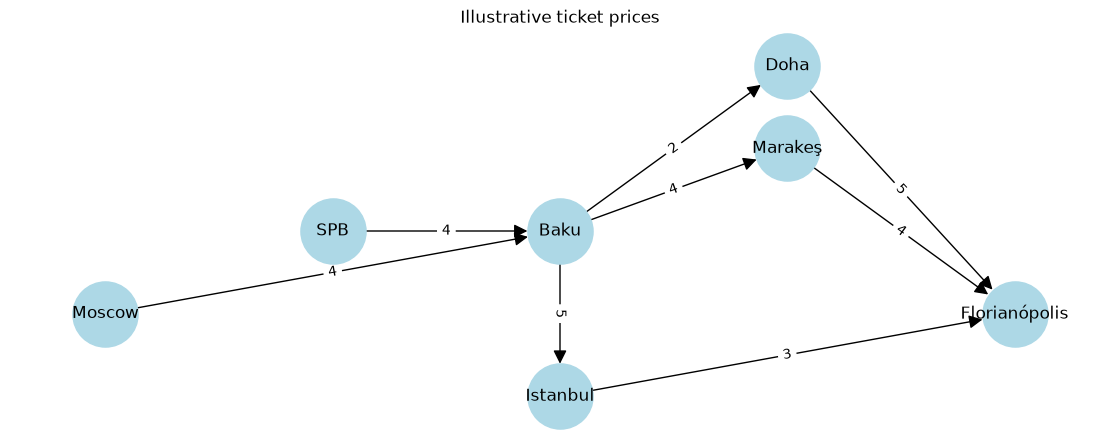

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo

START, END, VIA = "Moscow", "Florianópolis", "Baku"
G = nx.DiGraph()
G.add_weighted_edges_from([
    ("Moscow", "Baku", 4),
    ("SPB", "Baku", 4),
    ("Doha", "Florianópolis", 5),
    ("Baku", "Doha", 2),
    ("Baku", "Istanbul", 5),
    ("Baku", "Marakeş", 4),
    ("Istanbul", "Florianópolis", 3),
    ("Marakeş", "Florianópolis", 4)
], weight="cost")

# NetworkX handles the drawing, including the ticket-price labels.
pos = {"Moscow": (0, 0), "SPB": (1, 1), "Baku": (2, 1), "Florianópolis": (4, 0), "Doha": (3, 3), "Istanbul": (2, -1), "Marakeş": (3, 2)}
plt.figure(figsize=(11, 4))
nx.draw(G, pos, with_labels=True, node_size=2200, node_color="lightblue", arrowsize=20)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "cost"))
plt.title("Illustrative ticket prices")
plt.show()


## Route model and QUBO

Use one binary variable $x_{uv}$ for each arrow $u\to v$: 1 means the trip uses that leg. Minimize the sum of its ticket prices. At each city, the number of selected outgoing legs minus incoming legs must be $+1$ at the start, $-1$ at the destination, and 0 elsewhere. If Y is required, exactly one selected leg must enter Y. All prices are positive, so an optimal flow contains a simple path and no extra cycle.

`QuadraticProgramToQubo` converts these equality constraints into squared penalties, yielding $Q(x)=\sum c_{uv}x_{uv}+P\sum_v(\mathrm{out}_v-\mathrm{in}_v-b_v)^2$ (plus the optional Y penalty). The penalty is larger than the sum of all prices, so any constraint violation costs more than a valid trip. The multiplier starts at 2; larger values can help or hurt QAOA sampling. This tiny example uses seven qubits, one per binary variable.


In [2]:
edges = list(G.edges)
problem = QuadraticProgram("cheapest_city_trip")
for i in range(len(edges)):
    problem.binary_var(name=f"x{i}")
problem.minimize(linear={f"x{i}": G[u][v]["cost"] for i, (u, v) in enumerate(edges)})

# One unit of flow leaves START and arrives at END.
for city in G.nodes:
    flow = {f"x{i}": int(u == city) - int(v == city)
            for i, (u, v) in enumerate(edges)}
    balance = 1 if city == START else -1 if city == END else 0
    problem.linear_constraint(linear=flow, sense="==", rhs=balance, name=f"flow_{city}")
if VIA is not None:
    problem.linear_constraint(
        linear={f"x{i}": int(v == VIA) for i, (_, v) in enumerate(edges)},
        sense="==", rhs=1, name="visit_Y")



penalty_multiplier = 2  # Try 1 to compare with the previous run.
penalty = penalty_multiplier * (sum(G[u][v]["cost"] for u, v in edges) + 1)
converter = QuadraticProgramToQubo(penalty=penalty)
qubo = converter.convert(problem)
print("Constraint penalty:", penalty)
print("Edge variables:", {f"x{i}": f"{u} → {v}" for i, (u, v) in enumerate(edges)})
print(f"QUBO: {qubo.get_num_binary_vars()} binary variables, "
      f"{len(qubo.linear_constraints)} remaining constraints")
print(qubo.prettyprint())


Constraint penalty: 64
Edge variables: {'x0': 'Moscow → Baku', 'x1': 'Baku → Doha', 'x2': 'Baku → Istanbul', 'x3': 'Baku → Marakeş', 'x4': 'SPB → Baku', 'x5': 'Doha → Florianópolis', 'x6': 'Istanbul → Florianópolis', 'x7': 'Marakeş → Florianópolis'}
QUBO: 8 binary variables, 0 remaining constraints
Problem name: cheapest_city_trip

Minimize
  192*x0^2 - 128*x0*x1 - 128*x0*x2 - 128*x0*x3 + 256*x0*x4 + 128*x1^2
  + 128*x1*x2 + 128*x1*x3 - 128*x1*x4 - 128*x1*x5 + 128*x2^2 + 128*x2*x3
  - 128*x2*x4 - 128*x2*x6 + 128*x3^2 - 128*x3*x4 - 128*x3*x7 + 192*x4^2
  + 128*x5^2 + 128*x5*x6 + 128*x5*x7 + 128*x6^2 + 128*x6*x7 + 128*x7^2 - 252*x0
  + 2*x1 + 5*x2 + 4*x3 - 124*x4 - 123*x5 - 125*x6 - 124*x7 + 192

Subject to
  No constraints

  Binary variables (8)
    x0 x1 x2 x3 x4 x5 x6 x7



## Simulate QAOA and compare with a classical route

QAOA is a heuristic quantum optimization circuit. `StatevectorSampler` simulates its measurements locally, while COBYLA adjusts its circuit angles. The returned candidate is checked against the original route constraints. A classical NetworkX shortest-path calculation provides a reference answer. A sampled QAOA result may be infeasible or suboptimal; changing the seed, shot count, or circuit depth can change its result.


In [3]:
algorithm_globals.random_seed = 42  # Reproduce QAOA's initial angles.
qaoa = QAOA(sampler=StatevectorSampler(default_shots=8192, seed=42),
            optimizer=COBYLA(maxiter=100), reps=2)
result = MinimumEigenOptimizer(qaoa, converters=converter).solve(problem)

print("QAOA status:", result.status.name)
if result.status.name == "SUCCESS":
    selected_edges = [edge for bit, edge in zip(result.x, edges) if round(bit)]
    route = nx.shortest_path(nx.DiGraph(selected_edges), START, END)
    print("QAOA route:   ", " → ".join(route), "; cost:", result.fval)
else:
    print("QAOA did not sample a feasible route. Try more shots or repetitions.")


/Users/beilakaliev/projects/qdev/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/beilakaliev/projects/qdev/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/Users/beilakaliev/projects/qdev/.venv/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


QAOA status: SUCCESS
QAOA route:    Moscow → Baku → Doha → Florianópolis ; cost: 11.0


## The optimized quantum circuit

Each of the seven qubits represents one edge variable (`q_0` is `x0`, and so on). The circuit begins in a superposition, applies QUBO-dependent phase rotations (`RZ` and `RZZ`), mixes choices with `RX`, and finally measures all qubits. QAOA repeats the phase-and-mixer layers twice. The drawing expands the optimized circuit so the gates and measurements are visible.


Optimized QAOA circuit: 8 qubits, 2 layers


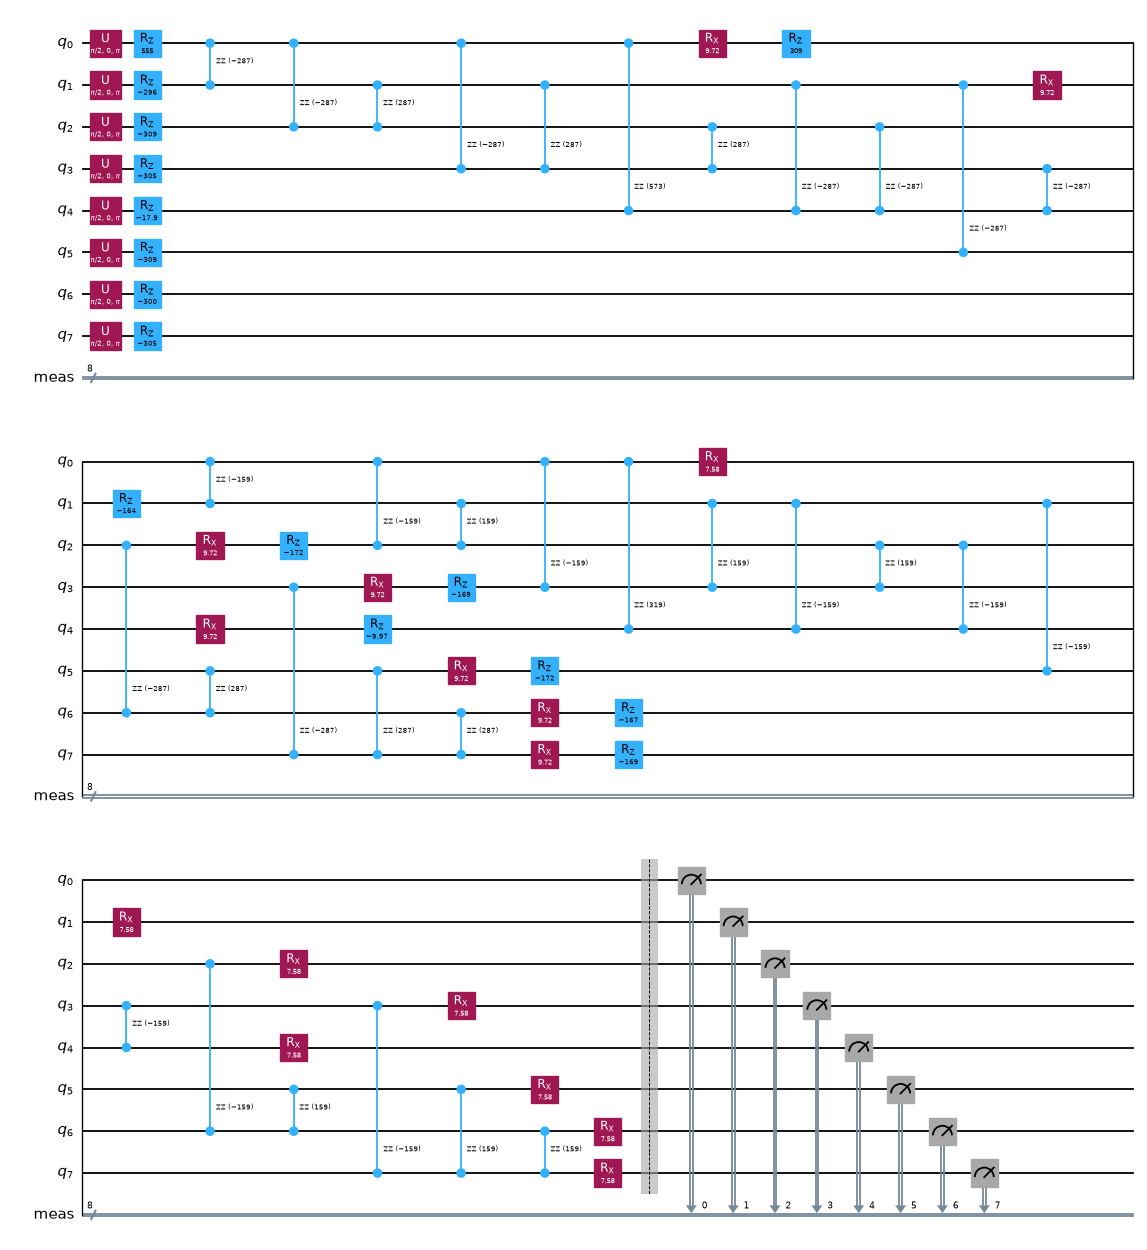

In [4]:
optimized = result.min_eigen_solver_result
circuit = optimized.optimal_circuit.assign_parameters(optimized.optimal_parameters)
print(f"Optimized QAOA circuit: {circuit.num_qubits} qubits, {qaoa.reps} layers")
circuit.decompose(reps=2).draw(output="mpl", fold=25, scale=0.65)


## Distribution after measurement

The sampler made 8,192 simulated measurements. Each seven-bit string records which edges were selected; the **rightmost** bit is `x0`. The first chart shows the 12 most frequent outcomes plus the rest. The second shows only outcomes that satisfy all route rules, using their original probabilities out of all shots. The tallest bar may be invalid: the optimizer reports the best **feasible** route found among the measured outcomes.


Probability of a valid trip: 1.9%
00100011: 1.7%; Moscow → Baku → Doha → Florianópolis
01000101: 0.2%; Moscow → Baku → Istanbul → Florianópolis


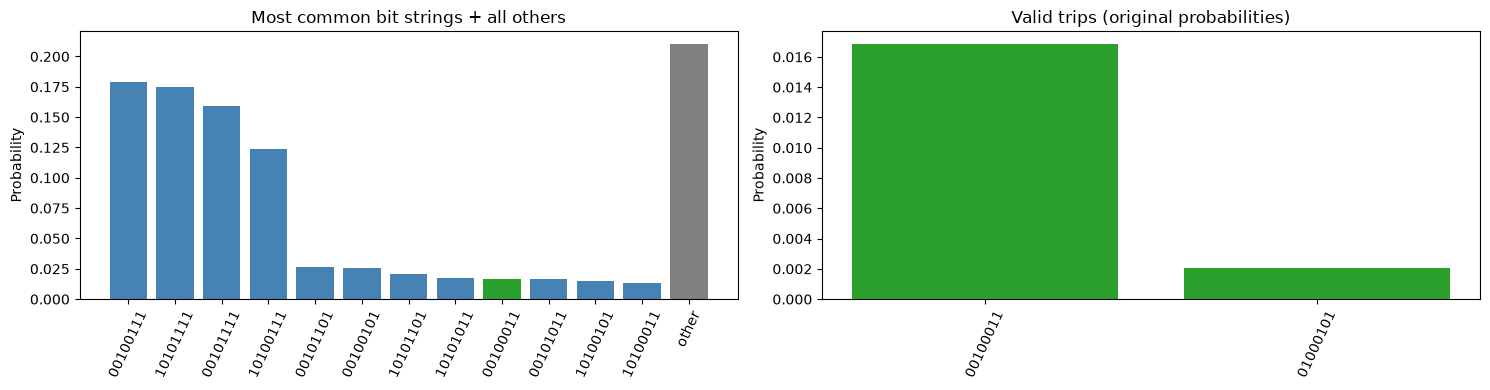

In [5]:
distribution = optimized.eigenstate  # Sampled bit-string probabilities.
valid = {bits: probability for bits, probability in distribution.items()
         if problem.is_feasible([int(bit) for bit in bits[::-1]])}
print(f"Probability of a valid trip: {sum(valid.values()):.1%}")
for bits, probability in sorted(valid.items(), key=lambda item: -item[1]):
    chosen = [edge for bit, edge in zip(bits[::-1], edges) if bit == "1"]
    trip = nx.shortest_path(nx.DiGraph(chosen), START, END)
    print(f"{bits}: {probability:.1%}; {' → '.join(trip)}")

# Keep the original probabilities: do not renormalize the filtered valid states.
top = sorted(distribution, key=distribution.get, reverse=True)[:12]
top_probabilities = [distribution[bits] for bits in top]
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].bar(top + ["other"], top_probabilities + [1 - sum(top_probabilities)],
            color=["tab:green" if bits in valid else "steelblue" for bits in top] + ["gray"])
axes[0].set_title("Most common bit strings + all others")
axes[1].bar(list(valid), list(valid.values()), color="tab:green")
axes[1].set_title("Valid trips (original probabilities)")
for ax in axes:
    ax.set_ylabel("Probability")
    ax.tick_params(axis="x", rotation=65)
plt.tight_layout()
plt.show()


### Notes

This is a small teaching example, not evidence of quantum advantage: QAOA is simulated on a classical computer, and NetworkX solves this graph directly. The QUBO method is useful here because it shows how ticket costs and route rules become a binary optimization problem. For larger graphs, the number of edge variables and QAOA simulation cost grow quickly.

References: [Qiskit Optimization QUBO and minimum-eigen optimizer](https://qiskit-community.github.io/qiskit-optimization/tutorials/03_minimum_eigen_optimizer.html), [NetworkX shortest paths](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path.html).
